**STEP 1: CT SCAN IMAGES UPLOAD**


In [4]:
!pip install ultralytics

IMPORTS

In [6]:
import os
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
import random
import matplotlib.image as mpimg
import tensorflow as tf
import zipfile
import os





In [8]:

# Replace 'baggage_dataset.zip' with your uploaded file name
with zipfile.ZipFile("/content/Threat_detection.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")  # extracts into a folder named "dataset"

# Check structure
os.listdir("dataset")

['NotThreats', 'ThreatsRGB', 'HighLow']

 **STEP 2: DATA PREPROCESSING**

FOLDER DIRECTORY

Folders: ['NotThreats', 'ThreatsRGB', 'HighLow']


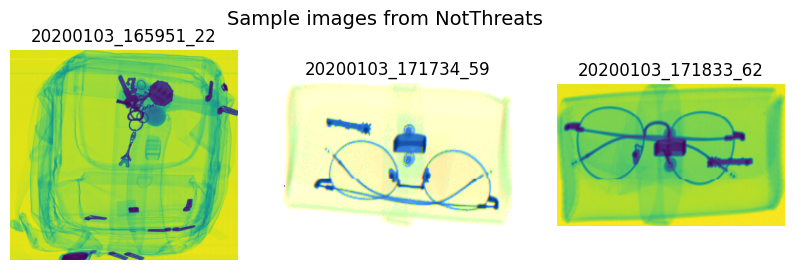

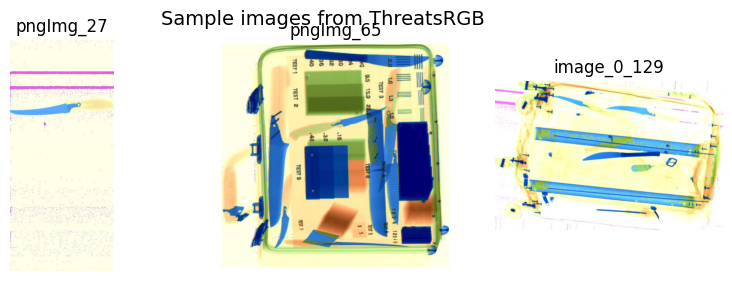

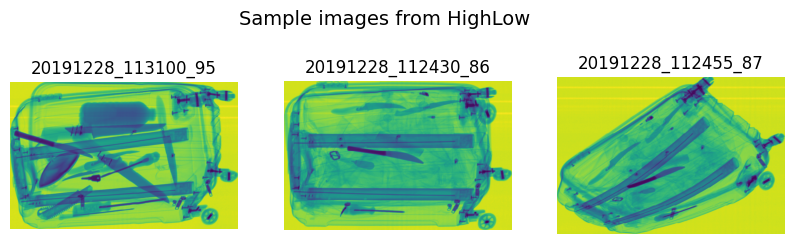

In [9]:
# Step 3: List folders
dataset_path = "dataset"
folders = os.listdir(dataset_path)
print("Folders:", folders)

# Step 4: Show 3 sample images from each folder
for folder in folders:
    folder_path = os.path.join(dataset_path, folder)
    images = os.listdir(folder_path)

    # Pick 3 random images
    sample_images = random.sample(images, min(3, len(images)))

    plt.figure(figsize=(10,3))
    plt.suptitle(f"Sample images from {folder}", fontsize=14)

    for i, img_name in enumerate(sample_images):
        img_path = os.path.join(folder_path, img_name)
        img = mpimg.imread(img_path)

        plt.subplot(1, 3, i+1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(img_name.split('.')[0])

    plt.show()







CHECK DATASET INFORMATION

In [10]:
# Count images in each folder
dataset_path = "dataset"
folders = os.listdir(dataset_path)

for folder in folders:
    folder_path = os.path.join(dataset_path, folder)
    num_images = len(os.listdir(folder_path))

    print(f"{folder} : {num_images} images")

NotThreats : 275 images
ThreatsRGB : 150 images
HighLow : 165 images


TRAINING - 80%

In [11]:
# Dataset path
dataset_path = "dataset"

# Load dataset
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    image_size=(224, 224),   # resize images
    batch_size=32,
    validation_split=0.2,
    subset="training",
    seed=42
)


Found 150 files belonging to 3 classes.
Using 120 files for training.


VALIDATION - 20%

In [12]:
validation_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    image_size=(224, 224),
    batch_size=32,
    validation_split=0.2,
    subset="validation",
    seed=42
)

Found 150 files belonging to 3 classes.
Using 30 files for validation.


NORMALIZATION

In [13]:
# Normalize training and validation datasets
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
validation_dataset = validation_dataset.map(lambda x, y: (normalization_layer(x), y))

DATA AUGMENTATION

In [14]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

# Apply to training dataset
train_dataset = train_dataset.map(lambda x, y: (data_augmentation(x, training=True), y))

In [15]:
train_dataset = train_dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

In [16]:
dataset_path = "dataset/images"

for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in files[:5]:  # show only first 5 images per folder
        print(f"{indent}    {f}")

**STEP 3: CHOOSING THE MODEL: YOLOv8- MODEL**

In [17]:
# Load pretrained YOLOv8 small model
model = YOLO('yolov8n.pt')

In [18]:
model = YOLO("yolov8n-cls.pt")   # classification model

model.train(
    data="dataset",        # IMPORTANT: point to dataset root
    epochs=20,
    imgsz=224,
    batch=16,
    name="baggage_classification"
)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=baggage_classification, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b926902e660>
curves: []
curves_results: []
fitness: 0.9957627058029175
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.991525411605835, 'metrics/accuracy_top5': 1.0, 'fitness': 0.9957627058029175}
save_dir: PosixPath('/content/runs/classify/baggage_classification')
speed: {'preprocess': 0.0013457542451560274, 'inference': 21.267214635588324, 'loss': 7.283050902099032e-05, 'postprocess': 0.00014375423927696706}
top1: 0.991525411605835
top5: 1.0

TEST

In [19]:
model.predict("/content/dataset_split/val/ThreatsRGB", show=True)

WARNING ⚠️ Environment does not support cv2.imshow() or PIL Image.show()


image 1/53 /content/dataset_split/val/ThreatsRGB/image_0_1000.jpg: 224x224 ThreatsRGB 1.00, NotThreats 0.00, HighLow 0.00, 21.7ms
image 2/53 /content/dataset_split/val/ThreatsRGB/image_0_1054.jpg: 224x224 ThreatsRGB 1.00, NotThreats 0.00, HighLow 0.00, 17.4ms
image 3/53 /content/dataset_split/val/ThreatsRGB/image_0_1071.jpg: 224x224 ThreatsRGB 1.00, NotThreats 0.00, HighLow 0.00, 16.7ms
image 4/53 /content/dataset_split/val/ThreatsRGB/image_0_1072.jpg: 224x224 ThreatsRGB 1.00, HighLow 0.00, NotThreats 0.00, 16.6ms
image 5/53 /content/dataset_split/val/ThreatsRGB/image_0_1212.jpg: 224x224 ThreatsRGB 1.00, NotThreats 0.00, HighLow 0.00, 16.3ms
image 6/53 /content/dataset_split/val/ThreatsRGB/image_0_1241.jpg: 224x224 ThreatsRGB 1.00, NotThreats 0.00, HighLow 0.00, 20.8ms
image 7/53 /content/dataset_split/val/ThreatsRGB/image_0_1321.jpg: 224x224 ThreatsRGB 1.00, NotThreats 0.00, HighLow 0.00, 17.9ms
image 8/53 /con

[ultralytics.engine.results.Results object with attributes:
 
 boxes: None
 keypoints: None
 masks: None
 names: {0: 'HighLow', 1: 'NotThreats', 2: 'ThreatsRGB'}
 obb: None
 orig_img: array([[[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        ...,
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255

MODEL EVALUATION

In [20]:
results = model.predict("/content/dataset_split/val/ThreatsRGB")




image 1/53 /content/dataset_split/val/ThreatsRGB/image_0_1000.jpg: 224x224 ThreatsRGB 1.00, NotThreats 0.00, HighLow 0.00, 16.7ms
image 2/53 /content/dataset_split/val/ThreatsRGB/image_0_1054.jpg: 224x224 ThreatsRGB 1.00, NotThreats 0.00, HighLow 0.00, 17.1ms
image 3/53 /content/dataset_split/val/ThreatsRGB/image_0_1071.jpg: 224x224 ThreatsRGB 1.00, NotThreats 0.00, HighLow 0.00, 17.0ms
image 4/53 /content/dataset_split/val/ThreatsRGB/image_0_1072.jpg: 224x224 ThreatsRGB 1.00, HighLow 0.00, NotThreats 0.00, 16.6ms
image 5/53 /content/dataset_split/val/ThreatsRGB/image_0_1212.jpg: 224x224 ThreatsRGB 1.00, NotThreats 0.00, HighLow 0.00, 16.2ms
image 6/53 /content/dataset_split/val/ThreatsRGB/image_0_1241.jpg: 224x224 ThreatsRGB 1.00, NotThreats 0.00, HighLow 0.00, 17.3ms
image 7/53 /content/dataset_split/val/ThreatsRGB/image_0_1321.jpg: 224x224 ThreatsRGB 1.00, NotThreats 0.00, HighLow 0.00, 17.3ms
image 8/53 /content/dataset_split/val/ThreatsRGB/image_0_1584.jpg: 224x224 ThreatsRGB 1.0

In [21]:
print("Predicted class:", results[0].names[results[0].probs.top1])
print("Confidence:", results[0].probs.top1conf)

Predicted class: ThreatsRGB
Confidence: tensor(1.0000)


CONVERTED IMAGES TO .JPG

In [22]:
from PIL import Image
import os
import shutil

# Base folder containing your split folders
base_folder = "/content/dataset_split"

# Iterate through splits and class folders
for split in ["train", "val", "test"]:
    split_path = os.path.join(base_folder, split)
    if not os.path.exists(split_path):
        continue

    for class_folder in os.listdir(split_path):
        class_path = os.path.join(split_path, class_folder)
        if not os.path.isdir(class_path):
            continue

        # Create a new folder for converted images
        converted_folder = class_path + "_jpg"
        os.makedirs(converted_folder, exist_ok=True)

        for file in os.listdir(class_path):
            if file.lower().endswith(".tif"):
                img_path = os.path.join(class_path, file)
                img = Image.open(img_path)

                # Convert to RGB if needed
                if img.mode != "RGB":
                    img = img.convert("RGB")

                # Save as JPG
                new_name = os.path.splitext(file)[0] + ".jpg"
                img.save(os.path.join(converted_folder, new_name))

print("All .tif images converted to .jpg successfully!")

All .tif images converted to .jpg successfully!


In [23]:
val_folder = "/content/dataset_split/val/NotThreats_jpg"

**STEP** **4**: **MODEL** **EVALUATION** **AND** **METRICES**


In [24]:
from ultralytics import YOLO
import os

# Load trained model
model = YOLO("/content/runs/classify/baggage_classification/weights/best.pt")

# Correct test folders (where your images actually are)
test_folders = [
    "/content/dataset_split/train/HighLow_jpg",

]

for folder in test_folders:
    print(f"Testing images in folder: {folder}\n{'-'*50}")

    # Include only image files
    image_files = [os.path.join(folder, f)
                   for f in os.listdir(folder)
                   if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    if not image_files:
        print("No images found!\n")
        continue

    for img_path in image_files:
        results = model(img_path)  # run prediction
        probs = results[0].probs   # get probabilities object

        pred_index = int(probs.top1)          # predicted class index
        confidence = float(probs.top1conf)    # confidence
        class_name = results[0].names[pred_index]  # class name

        print(f"Image: {os.path.basename(img_path)}")
        print(f"Predicted class: {class_name}, Confidence: {confidence:.2f}\n")

Testing images in folder: /content/dataset_split/train/HighLow_jpg
--------------------------------------------------

image 1/1 /content/dataset_split/train/HighLow_jpg/20191228_113510_101.xif_lo.jpg: 224x224 NotThreats 0.57, HighLow 0.42, ThreatsRGB 0.01, 21.2ms
Speed: 6.4ms preprocess, 21.2ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
Image: 20191228_113510_101.xif_lo.jpg
Predicted class: NotThreats, Confidence: 0.57


image 1/1 /content/dataset_split/train/HighLow_jpg/20191228_110209_64.xif_hi.jpg: 224x224 HighLow 0.66, ThreatsRGB 0.18, NotThreats 0.16, 16.3ms
Speed: 3.2ms preprocess, 16.3ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)
Image: 20191228_110209_64.xif_hi.jpg
Predicted class: HighLow, Confidence: 0.66


image 1/1 /content/dataset_split/train/HighLow_jpg/20191228_113510_101.xif_hi.jpg: 224x224 HighLow 0.41, NotThreats 0.38, ThreatsRGB 0.21, 17.1ms
Speed: 5.3ms preprocess, 17.1ms inference, 0.0ms postprocess per image at shape (1

THREAT MODEL EVALUATION- CONFIDENCE INTERVAL

In [25]:
from ultralytics import YOLO
import os

# Load trained model
model = YOLO("/content/runs/classify/baggage_classification/weights/best.pt")

# Correct test folders (where your images actually are)
test_folders = [
    "/content/dataset_split/train/ThreatsRGB",

]

for folder in test_folders:
    print(f"Testing images in folder: {folder}\n{'-'*50}")

    # Include only image files
    image_files = [os.path.join(folder, f)
                   for f in os.listdir(folder)
                   if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    if not image_files:
        print("No images found!\n")
        continue

    for img_path in image_files:
        results = model(img_path)  # run prediction
        probs = results[0].probs   # get probabilities object

        pred_index = int(probs.top1)          # predicted class index
        confidence = float(probs.top1conf)    # confidence
        class_name = results[0].names[pred_index]  # class name

        print(f"Image: {os.path.basename(img_path)}")
        print(f"Predicted class: {class_name}, Confidence: {confidence:.2f}\n")

Testing images in folder: /content/dataset_split/train/ThreatsRGB
--------------------------------------------------

image 1/1 /content/dataset_split/train/ThreatsRGB/image_0_1757.jpg: 224x224 ThreatsRGB 1.00, HighLow 0.00, NotThreats 0.00, 16.6ms
Speed: 5.4ms preprocess, 16.6ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
Image: image_0_1757.jpg
Predicted class: ThreatsRGB, Confidence: 1.00


image 1/1 /content/dataset_split/train/ThreatsRGB/image_0_1321.jpg: 224x224 ThreatsRGB 1.00, NotThreats 0.00, HighLow 0.00, 16.4ms
Speed: 5.1ms preprocess, 16.4ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
Image: image_0_1321.jpg
Predicted class: ThreatsRGB, Confidence: 1.00


image 1/1 /content/dataset_split/train/ThreatsRGB/image_0_776.jpg: 224x224 ThreatsRGB 1.00, NotThreats 0.00, HighLow 0.00, 17.2ms
Speed: 4.9ms preprocess, 17.2ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
Image: image_0_776.jpg
Predicted class: ThreatsRGB, Con

NON THREAT MODEL EVALUATION - CONFIDENCE INTERVAL



In [26]:
from ultralytics import YOLO
import os

# Load trained model
model = YOLO("/content/runs/classify/baggage_classification/weights/best.pt")

# Correct test folders (where your images actually are)
test_folders = [
    "/content/dataset_split/val/NotThreats_jpg",

]

for folder in test_folders:
    print(f"Testing images in folder: {folder}\n{'-'*50}")

    # Include only image files
    image_files = [os.path.join(folder, f)
                   for f in os.listdir(folder)
                   if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    if not image_files:
        print("No images found!\n")
        continue

    for img_path in image_files:
        results = model(img_path)  # run prediction
        probs = results[0].probs   # get probabilities object

        pred_index = int(probs.top1)          # predicted class index
        confidence = float(probs.top1conf)    # confidence
        class_name = results[0].names[pred_index]  # class name

        print(f"Image: {os.path.basename(img_path)}")
        print(f"Predicted class: {class_name}, Confidence: {confidence:.2f}\n")

Testing images in folder: /content/dataset_split/val/NotThreats_jpg
--------------------------------------------------

image 1/1 /content/dataset_split/val/NotThreats_jpg/20200103_170930_41.xif_hi.jpg: 224x224 HighLow 0.66, ThreatsRGB 0.18, NotThreats 0.16, 25.9ms
Speed: 7.8ms preprocess, 25.9ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)
Image: 20200103_170930_41.xif_hi.jpg
Predicted class: HighLow, Confidence: 0.66


image 1/1 /content/dataset_split/val/NotThreats_jpg/20200103_165118_4.xif_lo.jpg: 224x224 HighLow 0.66, ThreatsRGB 0.18, NotThreats 0.16, 26.1ms
Speed: 10.4ms preprocess, 26.1ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)
Image: 20200103_165118_4.xif_lo.jpg
Predicted class: HighLow, Confidence: 0.66


image 1/1 /content/dataset_split/val/NotThreats_jpg/20200103_172310_78.xif_hi.jpg: 224x224 HighLow 0.66, ThreatsRGB 0.18, NotThreats 0.16, 37.2ms
Speed: 4.4ms preprocess, 37.2ms inference, 0.1ms postprocess per image at shape (1, 3

**STEP** **5**: **METRICES** - **CONFUSION** **MATRIX**, **ACCURACY**, **F1**, **PRECISION**, **RECALL**

In [27]:
import os
from ultralytics import YOLO
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load your trained model (fine-tuned or original)
model = YOLO("/content/runs/classify/baggage_classification/weights/best.pt")  # adjust path

# Folders for evaluation (all classes)
eval_folders = {
    "NotThreats": "/content/dataset_split/train/HighLow_jpg",
    "HighLow": "/content/dataset_split/val/NotThreats_jpg",
    "ThreatsRGB": "/content/dataset_split/train/ThreatsRGB"
}

y_true = []
y_pred = []

# Loop through all folders & images
for class_name, folder_path in eval_folders.items():
    for filename in os.listdir(folder_path):
        if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(folder_path, filename)

            # Predict
            results = model(img_path)
            probs = results[0].probs
            pred_index = int(probs.top1)
            pred_label = results[0].names[pred_index]

            # Append true and predicted
            y_true.append(class_name)
            y_pred.append(pred_label)

# Compute metrics
accuracy = accuracy_score(y_true, y_pred)
print(f"\nOverall Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, labels=["NotThreats", "HighLow", "ThreatsRGB"], digits=4))

cm = confusion_matrix(y_true, y_pred, labels=["NotThreats", "HighLow", "ThreatsRGB"])
print("\nConfusion Matrix:")
print(cm)


image 1/1 /content/dataset_split/train/HighLow_jpg/20191228_113510_101.xif_lo.jpg: 224x224 NotThreats 0.57, HighLow 0.42, ThreatsRGB 0.01, 18.3ms
Speed: 6.4ms preprocess, 18.3ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)

image 1/1 /content/dataset_split/train/HighLow_jpg/20191228_110209_64.xif_hi.jpg: 224x224 HighLow 0.66, ThreatsRGB 0.18, NotThreats 0.16, 18.4ms
Speed: 5.6ms preprocess, 18.4ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)

image 1/1 /content/dataset_split/train/HighLow_jpg/20191228_113510_101.xif_hi.jpg: 224x224 HighLow 0.41, NotThreats 0.38, ThreatsRGB 0.21, 17.9ms
Speed: 7.2ms preprocess, 17.9ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)

image 1/1 /content/dataset_split/train/HighLow_jpg/20191228_115602_128.xif_hi.jpg: 224x224 HighLow 0.66, ThreatsRGB 0.18, NotThreats 0.16, 17.8ms
Speed: 7.1ms preprocess, 17.8ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)

image 1/1 /content/datas

In [28]:
for i, (true_label, pred_label) in enumerate(zip(y_true, y_pred)):
    print(f"{i}: True={true_label}, Pred={pred_label}")

0: True=NotThreats, Pred=NotThreats
1: True=NotThreats, Pred=HighLow
2: True=NotThreats, Pred=HighLow
3: True=NotThreats, Pred=HighLow
4: True=NotThreats, Pred=HighLow
5: True=NotThreats, Pred=HighLow
6: True=NotThreats, Pred=HighLow
7: True=NotThreats, Pred=HighLow
8: True=NotThreats, Pred=HighLow
9: True=NotThreats, Pred=HighLow
10: True=NotThreats, Pred=HighLow
11: True=NotThreats, Pred=HighLow
12: True=NotThreats, Pred=HighLow
13: True=NotThreats, Pred=HighLow
14: True=NotThreats, Pred=HighLow
15: True=NotThreats, Pred=HighLow
16: True=NotThreats, Pred=HighLow
17: True=NotThreats, Pred=HighLow
18: True=NotThreats, Pred=HighLow
19: True=NotThreats, Pred=HighLow
20: True=NotThreats, Pred=HighLow
21: True=NotThreats, Pred=HighLow
22: True=NotThreats, Pred=HighLow
23: True=NotThreats, Pred=HighLow
24: True=NotThreats, Pred=HighLow
25: True=NotThreats, Pred=HighLow
26: True=NotThreats, Pred=HighLow
27: True=NotThreats, Pred=HighLow
28: True=NotThreats, Pred=NotThreats
29: True=NotThreat

**STEP** **6**: **FINETUNING** **OF** **MODEL** **ADDED** **DATA** **AUGMENTATION** **TO** **IMPROVE** **THE** **METRICES**

In [29]:
from ultralytics import YOLO

# Load your existing model
model = YOLO("/content/runs/classify/baggage_classification/weights/best.pt")

# Set hyperparameters for fine-tuning
# - Lower learning rate to avoid catastrophic forgetting
# - Increase epochs for better convergence
# - Apply class weights to help NotThreats
hyperparams = {
    "lr0": 0.0001,         # initial learning rate
    "epochs": 30,          # fine-tune for 30 epochs
    "batch": 16,           # adjust depending on your GPU memory
    "weight_decay": 0.0005
}


# Train model with augmentation
model.train(
    data="/content/dataset_split",   # path to your dataset YAML or folder
    imgsz=224,
    batch=16,
    epochs=30,
    lr0=0.0001,
    optimizer="SGD",
    # class_weights=class_weights, # Removed invalid argument
    project="runs/classify/baggage_classification_finetune",
    name="NotThreats_finetuned",
    exist_ok=True
)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_split, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/runs/classify/baggage_classification/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=NotThreats_finetuned, nbs=64, nms=False, opset=None, optimize=False, 

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b92bbba5100>
curves: []
curves_results: []
fitness: 0.9092140793800354
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.8184281587600708, 'metrics/accuracy_top5': 1.0, 'fitness': 0.9092140793800354}
save_dir: PosixPath('/content/runs/classify/runs/classify/baggage_classification_finetune/NotThreats_finetuned')
speed: {'preprocess': 0.0011360189683188313, 'inference': 12.808177948512412, 'loss': 5.3707308596224704e-05, 'postprocess': 0.00011999458030401288}
top1: 0.8184281587600708
top5: 1.0

In [30]:
from ultralytics import YOLO
import os
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1️⃣ Load fine-tuned model
model = YOLO("/content/runs/classify/baggage_classification/weights/best.pt")

# 2️⃣ Define test folders with true labels
test_folders = {
    "NotThreats": "/content/dataset_split/val/NotThreats_jpg",
    "HighLow": "/content/dataset_split/val/HighLow_jpg",
    "ThreatsRGB": "/content/dataset_split/val/ThreatsRGB"
}

y_true = []
y_pred = []

# 3️⃣ Predict for all images
for true_label, folder in test_folders.items():
    for img_file in os.listdir(folder):
        if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(folder, img_file)
            results = model(img_path)
            probs = results[0].probs
            pred_index = int(probs.top1)
            pred_class = results[0].names[pred_index]

            y_true.append(true_label)
            y_pred.append(pred_class)

# 4️⃣ Compute metrics
accuracy = accuracy_score(y_true, y_pred)
print(f"Overall Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(
    y_true, y_pred,
    labels=["NotThreats", "HighLow", "ThreatsRGB"],
    digits=4
))

print("Confusion Matrix:")
cm = confusion_matrix(y_true, y_pred, labels=["NotThreats", "HighLow", "ThreatsRGB"])
print(cm)


image 1/1 /content/dataset_split/val/NotThreats_jpg/20200103_170930_41.xif_hi.jpg: 224x224 HighLow 0.66, ThreatsRGB 0.18, NotThreats 0.16, 28.0ms
Speed: 8.6ms preprocess, 28.0ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)

image 1/1 /content/dataset_split/val/NotThreats_jpg/20200103_165118_4.xif_lo.jpg: 224x224 HighLow 0.66, ThreatsRGB 0.18, NotThreats 0.16, 30.3ms
Speed: 11.2ms preprocess, 30.3ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)

image 1/1 /content/dataset_split/val/NotThreats_jpg/20200103_172310_78.xif_hi.jpg: 224x224 HighLow 0.66, ThreatsRGB 0.18, NotThreats 0.16, 26.7ms
Speed: 3.5ms preprocess, 26.7ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)

image 1/1 /content/dataset_split/val/NotThreats_jpg/20200103_171919_66.xif_hi.jpg: 224x224 HighLow 0.66, ThreatsRGB 0.18, NotThreats 0.16, 28.8ms
Speed: 5.7ms preprocess, 28.8ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)

image 1/1 /content/data

SAVE METRICES IN JSON FILE

In [31]:
# save_metrics.py
import os
import json
from ultralytics import YOLO
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Paths
model_path = "/content/runs/classify/baggage_classification/weights/best.pt"
test_folders = {
    "NotThreats": "/content/dataset_split/val/NotThreats_jpg",
    "HighLow": "/content/dataset_split/val/HighLow_jpg",
    "ThreatsRGB": "/content/dataset_split/val/ThreatsRGB"
}

# Load model
model = YOLO(model_path)

y_true = []
y_pred = []

# Predict all test images
for label, folder in test_folders.items():
    for f in os.listdir(folder):
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(folder, f)
            res = model(img_path)
            pred_index = int(res[0].probs.top1)
            pred_class = res[0].names[pred_index]
            y_true.append(label)
            y_pred.append(pred_class)

# Compute metrics
accuracy = accuracy_score(y_true, y_pred)
clf_report = classification_report(y_true, y_pred, labels=list(test_folders.keys()), digits=4, output_dict=True)
conf_matrix = confusion_matrix(y_true, y_pred, labels=list(test_folders.keys())).tolist()  # convert to list for JSON

# Save metrics as JSON
metrics = {
    "accuracy": accuracy,
    "classification_report": clf_report,
    "confusion_matrix": conf_matrix
}

with open("metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

print("Metrics saved to metrics.json")


image 1/1 /content/dataset_split/val/NotThreats_jpg/20200103_170930_41.xif_hi.jpg: 224x224 HighLow 0.66, ThreatsRGB 0.18, NotThreats 0.16, 19.4ms
Speed: 4.9ms preprocess, 19.4ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)

image 1/1 /content/dataset_split/val/NotThreats_jpg/20200103_165118_4.xif_lo.jpg: 224x224 HighLow 0.66, ThreatsRGB 0.18, NotThreats 0.16, 16.8ms
Speed: 5.3ms preprocess, 16.8ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)

image 1/1 /content/dataset_split/val/NotThreats_jpg/20200103_172310_78.xif_hi.jpg: 224x224 HighLow 0.66, ThreatsRGB 0.18, NotThreats 0.16, 16.6ms
Speed: 3.3ms preprocess, 16.6ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)

image 1/1 /content/dataset_split/val/NotThreats_jpg/20200103_171919_66.xif_hi.jpg: 224x224 HighLow 0.66, ThreatsRGB 0.18, NotThreats 0.16, 17.0ms
Speed: 3.4ms preprocess, 17.0ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)

image 1/1 /content/datas

**STEP** **7**: **DEPLOYMENT** **THROUGH** **GRADIO**

In [32]:
!pip install ultralytics gradio pillow

from ultralytics import YOLO
from PIL import Image
import gradio as gr

# Load your YOLO model
model = YOLO("/content/runs/classify/baggage_classification/weights/best.pt")  # replace with your trained model

def detect_image(img):
    results = model.predict(img, verbose=False)[0]
    annotated_img = results.plot()
    return annotated_img  # returns image with boxes

# Gradio interface
demo = gr.Interface(
    fn=detect_image,
    inputs=gr.Image(type="pil"),
    outputs=gr.Image(type="pil"),
    title="YOLO Threat Detection",
    description="Upload a baggage/CT scan image and see YOLO detections"
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4600d940d6442e5350.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
